In [1]:
%pip install optuna matplotlib seaborn tqdm scikit-learn shap

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.feature_selection import RFECV
from pygam import LinearGAM, s
from datetime import datetime
import joblib
import os

# ========= Load Dataset =========
df = pd.read_parquet(r"C:\hackathon\PS-03\model\finaldataset.parquet")  # Replace this
df= df.sample(n=400000,replace=True,random_state =42)
print("model training")
df['tir_radiance_diff'] = df['img_tir1_radiance'] - df['img_tir2_radiance']
df['pm25'] = df['pm25']
df['smoke_index_temp'] = df['img_mir_temp'] / (df['img_vis_radiance'] + 1e-6)
df['temp_diff_tir'] = df['img_tir1_temp'] - df['img_tir2_temp']
df['sat_view_obliquity'] = 90 - df['sat_elevation']   # how slanted the satellite view is
df['sun_view_angle_diff'] = abs(df['sun_azimuth'] - df['sat_azimuth'])  # illumination-view difference
df['sun_obliquity'] = 90 - df['sun_elevation']  # how low the sun is

# ========= Feature Lists =========
features_rf = [
    'latitude', 'longitude', 'img_mir_radiance', 'img_mir_temp', #'img_tir1_temp','img_tir2_temp','img_tir1_radiance', 'img_tir2_radiance','cloud_score','cloud_flag','inversion_flag',,'sun_obliquity''sat_view_obliquity', 'tir_radiance_diff'
    'img_swir_radiance', 'img_vis_radiance','smoke_index_temp',
    'img_vis_albedo', 'img_wv_radiance', 'img_wv_temp',
    'avg_population','PBLH', 'lulc','sun_view_angle_diff','sun_elevation','sun_azimuth','sat_elevation','sat_azimuth', 
    'temp_diff_tir'


]

features_xgb = [
    'latitude', 'longitude', 'img_mir_radiance', 'img_mir_temp', #'img_tir1_temp','img_tir2_temp','img_tir1_radiance', 'img_tir2_radiance', 'temp_diff_mir_wv','sat_azimuth', 'sat_elevation',,'inversion_flag','cloud_score','cloud_flag', ,'img_vis_albedo',
    'img_swir_radiance', 'img_vis_radiance','smoke_index_temp',
    'img_wv_radiance',
    'avg_population','PBLH', 'lulc', 'tir_radiance_diff','sat_view_obliquity','sun_view_angle_diff','sun_obliquity','img_wv_temp',
    'sun_elevation','sun_azimuth',
    'temp_diff_tir'

]

features_lgb = [
    'latitude', 'longitude', 'img_mir_radiance', #'img_mir_temp', 'img_tir1_temp','img_tir2_temp','img_tir1_radiance', 'img_tir2_radiance', 'img_wv_radiance', ,'sat_view_obliquity,'sun_elevation'
    'img_swir_radiance', 'img_vis_radiance','smoke_index_temp','sun_azimuth', ''
    'img_vis_albedo','avg_population','PBLH', 'lulc', 'tir_radiance_diff','sun_view_angle_diff','sun_obliquity','sat_elevation','img_wv_temp',
    'temp_diff_tir','img_wv_temp','sat_azimuth'
]

features_stack = list(set(features_rf + features_xgb + features_lgb))
features_gam = ['rf_pred', 'stack_pred', 'latitude', 'longitude', 'img_vis_radiance', 'img_wv_temp']
target = 'pm25'

df = df.dropna(subset=features_stack + [target])
y = df[target]

# ========= Split Data per Model =========
X_rf = df[features_rf]
X_xgb = df[features_xgb]
X_lgb = df[features_lgb]
X_stack = df[features_stack]

X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(X_rf, y, test_size=0.2, random_state=42)
X_xgb_train, X_xgb_test, y_xgb_train, y_xgb_test = train_test_split(X_xgb, y, test_size=0.2, random_state=42)
X_lgb_train, X_lgb_test, y_lgb_train, y_lgb_test = train_test_split(X_lgb, y, test_size=0.2, random_state=42)
X_stack_train, X_stack_test, y_stack_train, y_stack_test = train_test_split(X_stack, y, test_size=0.2, random_state=42)

# ========= Random Forest =========
rf_best = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(
        n_estimators=600,
        max_depth=44,
        min_samples_split=5,
        min_samples_leaf=1,
        max_features=7,
        random_state=42))
])
rf_best.fit(X_rf_train, y_rf_train)
rf_preds = rf_best.predict(X_rf_test)

# ========= XGBoost =========
xgb_best = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(
        n_estimators=600,
        max_depth=38,
        learning_rate=0.055583515998437666,
        subsample=0.6406727063988964,
        colsample_bytree=0.6086705817021152,
        gamma= 4.971443993130478,
        reg_alpha=0.7247001641882442,
        reg_lambda=0.8893176484870176,
        min_child_weight=8))
])
xgb_best.fit(X_xgb_train, y_xgb_train)
xgb_preds = xgb_best.predict(X_xgb_test)

# ========= LightGBM =========
lgb_best = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LGBMRegressor(
        n_estimators=600,
        max_depth=25,
        learning_rate=0.25791583493355,
        subsample=0.6520687028680755,
        colsample_bytree=0.9183624262964711,
        min_child_weight=2,
        reg_alpha=0.6108075549420471,
        reg_lambda=0.775489349900625,
        random_state=42))
])
lgb_best.fit(X_lgb_train, y_lgb_train)
lgb_preds = lgb_best.predict(X_lgb_test)

# ========= Stacking Regressor =========
model_scores = {
    'XGBoost': r2_score(y_xgb_test, xgb_preds),
    'LightGBM': r2_score(y_lgb_test, lgb_preds),
}
best_two = sorted(model_scores, key=model_scores.get, reverse=True)[:2]
model_dict = {
    'XGBoost': xgb_best.named_steps['model'],
    'LightGBM': lgb_best.named_steps['model'],
}

stack_reg = StackingRegressor(
    estimators=[(best_two[0], model_dict[best_two[0]]),
                (best_two[1], model_dict[best_two[1]])],
    final_estimator=RandomForestRegressor(n_estimators=150, random_state=42),
    passthrough=True
)
stack_pipeline = Pipeline([('scaler', StandardScaler()), ('model', stack_reg)])
stack_pipeline.fit(X_stack_train, y_stack_train)
stack_preds = stack_pipeline.predict(X_stack_test)

# ========= Final GAM =========
gam_input = pd.DataFrame({
    'rf_pred': rf_preds,
    'stack_pred': stack_preds,
    'latitude': X_stack_test['latitude'].values,
    'longitude': X_stack_test['longitude'].values,
    'img_vis_radiance': X_stack_test['img_vis_radiance'].values,
    'img_wv_temp': X_stack_test['img_wv_temp'].values,
    # 'day_sin': X_stack_test['day_sin'].values
})
final_gam = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4) + s(5))
final_gam.gridsearch(gam_input.values, y_stack_test.values)
final_preds = final_gam.predict(gam_input.values)

# ========= Evaluation =========
def print_metrics(y_true, y_pred, label):
    print(f"\n📊 {label}")
    print("R² Score:", round(r2_score(y_true, y_pred), 4))
    print("MAE:", round(mean_absolute_error(y_true, y_pred), 4))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_true, y_pred)), 4))

print_metrics(y_rf_test, rf_preds, "Random Forest")
print_metrics(y_xgb_test, xgb_preds, "XGBoost")
print_metrics(y_lgb_test, lgb_preds, "LightGBM")
print_metrics(y_stack_test, stack_preds, "Stacking Model")
print_metrics(y_stack_test, final_preds, "Final Ensemble (GAM over RF + Stack)")

# ========= Save Everything =========
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_dir = f"pm2.5_1_model/{timestamp}"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(rf_best, f"{model_dir}/rf_best_model.pkl")
joblib.dump(xgb_best, f"{model_dir}/xgb_best_model.pkl")
joblib.dump(lgb_best, f"{model_dir}/lgb_best_model.pkl")
joblib.dump(stack_pipeline, f"{model_dir}/stacking_model.pkl")
joblib.dump(final_gam, f"{model_dir}/final_gam_ensemble.pkl")
np.save(f"{model_dir}/X_test.npy", X_stack_test)
np.save(f"{model_dir}/y_test.npy", y_stack_test)
np.save(f"{model_dir}/rf_preds.npy", rf_preds)
np.save(f"{model_dir}/stack_preds.npy", stack_preds)
np.save(f"{model_dir}/final_preds.npy", final_preds)
gam_input.to_csv(f"{model_dir}/gam_input.csv", index=False)
pd.Series(rf_best.named_steps['model'].feature_importances_, index=X_rf.columns).sort_values(ascending=False).to_csv(f"{model_dir}/rf_feature_importance.csv")


start
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007601 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4670
[LightGBM] [Info] Number of data points in the train set: 306431, number of used features: 19
[LightGBM] [Info] Start training from score 48.623728
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009693 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5435
[LightGBM] [Info] Number of data points in the train set: 306431, number of used features: 22
[LightGBM] [Info] Start training from score 48.623728
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007993 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5434
[LightGBM] [Info] Number of data points in the train set: 245144, number of used features: 22
[LightGBM] [Info

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:03 ETA:   0:00:38
 18% (2 of 11) |####                     | Elapsed Time: 0:00:07 ETA:   0:00:34
 27% (3 of 11) |######                   | Elapsed Time: 0:00:11 ETA:   0:00:30
 36% (4 of 11) |#########                | Elapsed Time: 0:00:15 ETA:   0:00:26
 45% (5 of 11) |###########              | Elapsed Time: 0:00:19 ETA:   0:00:22
 54% (6 of 11) |#############            | Elapsed Time: 0:00:22 ETA:   0:00:18
 63% (7 of 11) |###############          | Elapsed Time: 0:00:26 ETA:   0:00:15
 72% (8 of 11) |##################       | Elapsed Time: 0:00:30 ETA:   0:00:11
 81% (9 of 11) |####################     | Elapsed Time: 0:00:33 ETA:   0:00:07
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:37 ETA:   0:00:03
100% (11 of 11) |########################| Elapsed Time: 0:00:41 Time:  0:00:41



📊 Random Forest
R² Score: 0.7981
MAE: 12.4407
RMSE: 20.6626

📊 XGBoost
R² Score: 0.7969
MAE: 12.4502
RMSE: 20.7233

📊 LightGBM
R² Score: 0.7981
MAE: 12.4593
RMSE: 20.6625

📊 Stacking Model
R² Score: 0.7982
MAE: 12.4309
RMSE: 20.6553

📊 Final Ensemble (GAM over RF + Stack)
R² Score: 0.8
MAE: 12.4012
RMSE: 20.5651



📊 Random Forest
R² Score       : 0.7029
Adjusted R²    : 0.7026
MAE            : 12.4938
RMSE           : 18.8670

📊 Stacking Model
R² Score       : 0.7551
Adjusted R²    : 0.7548
MAE            : 11.0471
RMSE           : 17.1301

📊 Final Ensemble (GAM)
R² Score       : 0.7572
Adjusted R²    : 0.7571
MAE            : 10.9794
RMSE           : 17.0559

✅ Metrics saved to: C:\isro\maindataset\pm2.5_complete\pm2.5_crtaod\20250804_183337\model_metrics_summary.csv


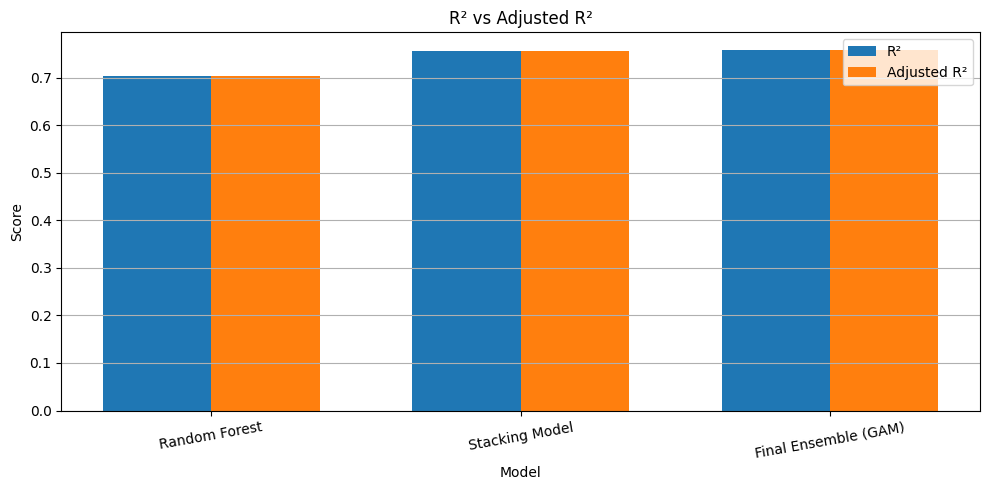

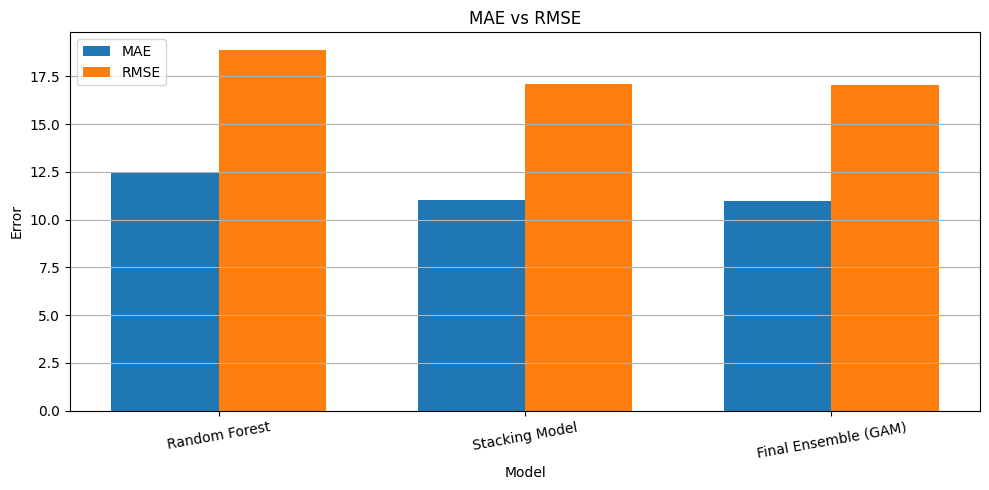

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os

# === Load saved predictions and test data ===
model_dir = r"C:\isro\maindataset\pm2.5_complete\pm2.5_crtaod\20250804_183337"  # 🔁 Update if needed

X_test = np.load(f"{model_dir}/X_test.npy", allow_pickle=True)
y_test = np.load(f"{model_dir}/y_test.npy", allow_pickle=True)
rf_preds = np.load(f"{model_dir}/rf_preds.npy", allow_pickle=True)
stack_preds = np.load(f"{model_dir}/stack_preds.npy", allow_pickle=True)
final_preds = np.load(f"{model_dir}/final_preds.npy", allow_pickle=True)
gam_input = pd.read_csv(f"{model_dir}/gam_input.csv")

# === Adjusted R² Calculation ===
def adjusted_r2_score(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

# === Collect metrics for all models ===
summary = []

models_info = [
    ("Random Forest", rf_preds, X_test.shape[1]),
    ("Stacking Model", stack_preds, X_test.shape[1]),
    ("Final Ensemble (GAM)", final_preds, gam_input.shape[1]),
]

for name, preds, k in models_info:
    n = len(y_test)
    r2 = r2_score(y_test, preds)
    adj_r2 = adjusted_r2_score(r2, n, k)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    print(f"\n📊 {name}")
    print(f"R² Score       : {r2:.4f}")
    print(f"Adjusted R²    : {adj_r2:.4f}")
    print(f"MAE            : {mae:.4f}")
    print(f"RMSE           : {rmse:.4f}")
    
    summary.append({
        "Model": name,
        "R2": r2,
        "Adjusted R2": adj_r2,
        "MAE": mae,
        "RMSE": rmse
    })

# === Save all metrics to CSV ===
summary_df = pd.DataFrame(summary)
metrics_path = os.path.join(model_dir, "model_metrics_summary.csv")
summary_df.to_csv(metrics_path, index=False)
print(f"\n✅ Metrics saved to: {metrics_path}")

# === Plot R² vs Adjusted R² ===
plt.figure(figsize=(10, 5))
x = np.arange(len(summary_df["Model"]))
bar_width = 0.35

plt.bar(x, summary_df["R2"], width=bar_width, label='R²')
plt.bar(x + bar_width, summary_df["Adjusted R2"], width=bar_width, label='Adjusted R²')

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("R² vs Adjusted R²")
plt.xticks(x + bar_width / 2, summary_df["Model"], rotation=10)
plt.legend()
plt.tight_layout()
plt.grid(axis='y')
plt.show()

# === Plot MAE vs RMSE ===
plt.figure(figsize=(10, 5))
plt.bar(x, summary_df["MAE"], width=bar_width, label='MAE')
plt.bar(x + bar_width, summary_df["RMSE"], width=bar_width, label='RMSE')

plt.xlabel("Model")
plt.ylabel("Error")
plt.title("MAE vs RMSE")
plt.xticks(x + bar_width / 2, summary_df["Model"], rotation=10)
plt.legend()
plt.tight_layout()
plt.grid(axis='y')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import joblib

# === File paths ===
data_path = "C:\hackathon\PS-03\model\finaldataset.parquet"
rf_model_path = "C:/hackathon/PS-03/model/pm2.5_1_model/20250808_043409/rf_best_model.pkl"
stack_model_path = "C:/hackathon/PS-03/model/pm2.5_1_model/20250808_043409/stacking_model.pkl"
gam_model_path = "C:/hackathon/PS-03/model/pm2.5_1_model/20250808_043409/final_gam_ensemble.pkl"

# === Load data ===
df = pd.read_parquet(data_path)

# === Feature Engineering ===
df['tir_radiance_diff'] = df['img_tir1_radiance'] - df['img_tir2_radiance']
df['smoke_index_temp'] = df['img_mir_temp'] / (df['img_vis_radiance'] + 1e-6)
df['temp_diff_tir'] = df['img_tir1_temp'] - df['img_tir2_temp']
df['sat_view_obliquity'] = 90 - df['sat_elevation']
df['sun_view_angle_diff'] = abs(df['sun_azimuth'] - df['sat_azimuth'])
df['sun_obliquity'] = 90 - df['sun_elevation']

# === Define model-specific feature sets ===
features_rf = [
    'latitude', 'longitude', 'img_mir_radiance', 'img_mir_temp',
    'img_swir_radiance', 'img_vis_radiance', 'smoke_index_temp',
    'img_vis_albedo', 'img_wv_radiance', 'img_wv_temp',
    'avg_population', 'PBLH', 'lulc', 'sun_view_angle_diff',
    'sun_elevation', 'sun_azimuth', 'sat_elevation', 'sat_azimuth',
    'temp_diff_tir'
]

features_xgb = [
    'latitude', 'longitude', 'img_mir_radiance', 'img_mir_temp',
    'img_swir_radiance', 'img_vis_radiance', 'smoke_index_temp',
    'img_wv_radiance', 'avg_population', 'PBLH', 'lulc',
    'tir_radiance_diff', 'sat_view_obliquity', 'sun_view_angle_diff',
    'sun_obliquity', 'img_wv_temp', 'sun_elevation', 'sun_azimuth',
    'temp_diff_tir'
]

features_lgb = [
    'latitude', 'longitude', 'img_mir_radiance', 'img_swir_radiance',
    'img_vis_radiance', 'smoke_index_temp', 'sun_azimuth',
    'img_vis_albedo', 'avg_population', 'PBLH', 'lulc',
    'tir_radiance_diff', 'sun_view_angle_diff', 'sun_obliquity',
    'sat_elevation', 'img_wv_temp', 'temp_diff_tir', 'sat_azimuth'
]

features_stack = list(set(features_rf + features_xgb + features_lgb))

features_gam = ['rf_pred', 'stack_pred', 'latitude', 'longitude', 'img_vis_radiance', 'img_wv_temp']

# === Drop rows with missing values in any used features or target ===
# Only include original features used (exclude prediction-based columns)
features_gam_required = [col for col in features_gam if col not in ['rf_pred', 'stack_pred']]
required_features = list(set(features_rf + features_xgb + features_lgb + features_gam_required + ['pm25']))

df = df.dropna(subset=required_features).copy()

# === Load models ===
rf_model = joblib.load(rf_model_path)
stack_model = joblib.load(stack_model_path)
gam_model = joblib.load(gam_model_path)

# === Intermediate Predictions ===
X_rf = df[features_rf]
X_stack = df[features_stack]

df['rf_pred'] = rf_model.predict(X_rf)
df['stack_pred'] = stack_model.predict(X_stack)

# === Final GAM input and prediction ===
gam_input_all = df[features_gam]
df['predicted_pm25'] = gam_model.predict(gam_input_all.values)

# === Optional: Add error columns for debugging ===
df['abs_error'] = np.abs(df['predicted_pm25'] - df['pm25'])
df['error'] = df['predicted_pm25'] - df['pm25']

# === Print Error Summary ===
print("📊 Mean Absolute Error (MAE):", df['abs_error'].mean())
print("📉 Mean Error (Bias):", df['error'].mean())

# === Preview Final DataFrame with all original and new columns ===
print(df[['pm25', 'predicted_pm25', 'abs_error', 'error']].head())

#Optional: Save full DataFrame with predictions
df.to_parquet("C:/hackathon/PS-03/model/predicted_with_all_features.parquet")


📊 Mean Absolute Error (MAE): 12.252805743338788
📉 Mean Error (Bias): -0.05916293898047345
    pm25  predicted_pm25  abs_error      error
0  16.52       19.908919   3.388919   3.388919
1  33.00       17.220622  15.779378 -15.779378
2  33.00       17.220622  15.779378 -15.779378
3  33.00       17.220622  15.779378 -15.779378
4  33.00       17.220622  15.779378 -15.779378


In [56]:
import pandas as pd
df = pd.read_parquet(r"C:\hackathon\PS-03\model\predicted_with_all_features.parquet")
df

,Date,latitude,longitude,pm25,pm10,img_mir_radiance,img_mir_temp,img_swir_radiance,img_tir1_radiance,img_tir1_temp,...,smoke_index_temp,temp_diff_tir,sat_view_obliquity,sun_view_angle_diff,sun_obliquity,rf_pred,stack_pred,predicted_pm25,abs_error,error
0,2021-01-15,8.514909,76.943588,16.520000,37.840000,0.043679,290.781586,1.312773,0.520951,263.632935,...,43.373391,5.901184,-7732.263158,6083.894737,-5510.421053,17.600566,21.549704,19.908919,3.388919,3.388919
1,2021-01-15,8.524112,76.936057,33.000000,51.750000,0.043498,290.683807,1.350298,0.521067,263.644684,...,41.548022,6.083618,-7731.000000,6083.842105,-5510.157895,16.798380,16.943352,17.220622,15.779378,-15.779378
2,2021-01-15,8.524112,76.936057,33.000000,38.500000,0.043498,290.683807,1.350298,0.521067,263.644684,...,41.548022,6.083618,-7731.000000,6083.842105,-5510.157895,16.798380,16.943352,17.220622,15.779378,-15.779378
3,2021-01-15,8.524112,76.936057,33.000000,33.500000,0.043498,290.683807,1.350298,0.521067,263.644684,...,41.548022,6.083618,-7731.000000,6083.842105,-5510.157895,16.798380,16.943352,17.220622,15.779378,-15.779378
4,2021-01-15,8.524112,76.936057,33.000000,39.000000,0.043498,290.683807,1.350298,0.521067,263.644684,...,41.548022,6.083618,-7731.000000,6083.842105,-5510.157895,16.798380,16.943352,17.220622,15.779378,-15.779378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395094,2023-11-15,34.065992,74.827902,61.900000,69.700000,0.052602,295.190308,0.997179,0.814765,289.112488,...,79.389930,1.449402,-4975.187500,3573.187500,-3428.312500,41.655753,41.730068,41.414853,20.485147,-20.485147
395095,2023-11-15,34.065992,74.827902,61.900000,70.000000,0.052602,295.190308,0.997179,0.814765,289.112488,...,79.389930,1.449402,-4975.187500,3573.187500,-3428.312500,41.655753,41.730068,41.414853,20.485147,-20.485147
395096,2023-11-15,34.065992,74.827902,61.900000,188.100000,0.052602,295.190308,0.997179,0.814765,289.112488,...,79.389930,1.449402,-4975.187500,3573.187500,-3428.312500,41.655753,41.730068,41.414853,20.485147,-20.485147
395097,2023-11-15,34.065992,74.827902,61.900000,187.500000,0.052602,295.190308,0.997179,0.814765,289.112488,...,79.389930,1.449402,-4975.187500,3573.187500,-3428.312500,41.655753,41.730068,41.414853,20.485147,-20.485147
